# 10 · Clustering

Clustering groups points by similarity with no target column to guide it.
This notebook walks through
**k-means**, which partitions points into `k` clusters around learned
centroids, and then *watches it converge*: with `track_history=True` the
fit records every centroid position and every point-to-cluster assignment,
which we replay as a matplotlib animation.

Then we swap in a second dataset — the same blobs, but with a handful of
extreme outliers — to contrast k-means against **k-medians**. Same
alternating fit, but the update step takes the coordinate-wise *median*
instead of the mean, which makes the centroids shrug off outliers that
drag a k-means centroid well off its cluster.

## K-means

`KMeans.fit` initialises `k` centroids (`"kmeans++"` by default, or
`"random"`), then alternates two steps until the centroids stop moving:

1. **assign** — each point joins its nearest centroid (Euclidean distance);
2. **update** — each centroid moves to the mean of its assigned points.

Passing `track_history=True` stores one snapshot per iteration in
`centroids_history` (a `(k, 2)` array) and `assignments_history` (an
`(n,)` array of cluster indices), which we replay as an animation below.

### Data

Three Gaussian blobs, loaded into a `DolceSet` with no target column since
clustering is unsupervised. Two features (`x1`, `x2`) so we can plot the
whole thing.

In [1]:
import numpy as np
import polars as pl

from dolcestat.preprocessing import DolceSet

rng = np.random.default_rng(0)
centers = np.array([[0, 0], [5, 5], [0, 5]])
n_per_cluster = 100

points = np.vstack(
    [center + rng.normal(0, 0.75, (n_per_cluster, 2)) for center in centers]
)
df = pl.DataFrame({"x1": points[:, 0], "x2": points[:, 1]})

data = DolceSet()
data.load_from_polars_dataframe(df)

### The fit

We use `"random"` init here so the first frame starts visibly off the
blobs and the animation has something to show; `random` init draws from
NumPy's global RNG, so we seed it for a reproducible run.

In [2]:
from dolcestat.clustering import KMeans

np.random.seed(13)  # 'random' init uses the global RNG; pin it for reproducibility
kmeans = KMeans()
kmeans.fit(data, k=3, init_strategy="random", max_iters=100, track_history=True)

print(f"converged in {kmeans.n_iters} iterations")
print("final centroids:")
print(np.round(kmeans.centroids, 3))

converged in 5 iterations
final centroids:
[[-0.044  5.052]
 [-0.053  0.076]
 [ 4.906  4.961]]


### Watching it converge

Each animation frame is one iteration: points are coloured by their cluster
assignment *at that iteration*, the large diamonds are the centroids, and the
faint trails show where each centroid has travelled so far. Early frames
reshuffle large groups of points; by the last frame nothing moves.

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

sns.set_theme()

X = data.X
centroids_hist = np.stack(kmeans.centroids_history)      # (n_iters, k, 2)
assign_hist = np.stack(kmeans.assignments_history)       # (n_iters, n)
n_iters, k, _ = centroids_hist.shape
palette = np.array(sns.color_palette("deep", k))

fig, ax = plt.subplots(figsize=(6, 6))
pad = 0.7
ax.set_xlim(X[:, 0].min() - pad, X[:, 0].max() + pad)
ax.set_ylim(X[:, 1].min() - pad, X[:, 1].max() + pad)
ax.set_xlabel("x1")
ax.set_ylabel("x2")

scatter = ax.scatter(X[:, 0], X[:, 1], s=18, alpha=0.7)
trails = [ax.plot([], [], color=palette[j], lw=1, alpha=0.4)[0] for j in range(k)]
centroid_marker = ax.scatter(
    centroids_hist[0, :, 0],
    centroids_hist[0, :, 1],
    marker="D",
    s=200,
    c=palette,
    edgecolors="black",
    linewidths=1.5,
    zorder=3,
)


def update(frame):
    scatter.set_color(palette[assign_hist[frame]])
    centroid_marker.set_offsets(centroids_hist[frame])
    for j, trail in enumerate(trails):
        trail.set_data(
            centroids_hist[: frame + 1, j, 0],
            centroids_hist[: frame + 1, j, 1],
        )
    ax.set_title(f"iteration {frame + 1} / {n_iters}")
    return [scatter, centroid_marker, *trails]


anim = FuncAnimation(fig, update, frames=n_iters, interval=900, blit=False)
plt.close(fig)  # don't also show the static final frame
HTML(anim.to_jshtml())

## Choosing `k`

The animation above used `k=3` because we *built* three blobs. On real data
there's no such luxury — `k` is a hyperparameter, and k-means will happily
partition into however many clusters you ask for. Two standard diagnostics
help pick a value:

- **Elbow / WCSS.** After each fit, `KMeans` exposes `wcss` — the
  within-cluster sum of *squared* distances from every point to its centroid
  (the same quantity scikit-learn calls `inertia_`). It falls monotonically
  as `k` grows: more centroids can only tighten clusters, and at `k = n`
  it hits zero. The useful signal is the *rate* of decline — a sharp bend
  ("elbow") where extra clusters stop buying much. On clean blobs the elbow
  sits right at the true count.

- **Silhouette.** For each point, let `a` be its mean distance to the other
  points in its own cluster and `b` its mean distance to the nearest *other*
  cluster; its silhouette is `(b - a) / max(a, b)`, ranging from `-1`
  (probably misassigned) through `0` (on a boundary) to `+1` (deep inside a
  well-separated cluster). `KMeans.silhouette` is the mean over all points.
  Unlike WCSS it isn't monotone in `k`, so you can just take the `k` that
  maximises it. It's undefined for `k = 1` (no "other cluster"), so that
  entry comes back as `nan`.

We sweep `k` from 1 to 10 on the original three-blob dataset and read both.

In [4]:
k_values = range(1, 11)
wcss = []
silhouette = []

for k_try in k_values:
    np.random.seed(0)  # 'kmeans++' draws its first centroid from the global RNG
    model = KMeans()
    model.fit(data, k=k_try, init_strategy="kmeans++", max_iters=100)
    wcss.append(model.wcss)
    silhouette.append(model.silhouette)

print(f"{'k':>3}  {'WCSS':>10}  {'silhouette':>10}")
for k_try, w, s in zip(k_values, wcss, silhouette):
    print(f"{k_try:>3}  {w:>10.2f}  {s:>10.4f}")

best_k = k_values[int(np.nanargmax(silhouette))]
print(f"\nsilhouette is maximised at k = {best_k}")

  k        WCSS  silhouette
  1     3590.90         nan
  2     1552.60      0.5600
  3      333.17      0.7252
  4      295.15      0.5794
  5      256.56      0.4381
  6      234.54      0.4439
  7      224.86      0.4254
  8      183.40      0.3272
  9      162.19      0.3255
 10      145.38      0.3339

silhouette is maximised at k = 3


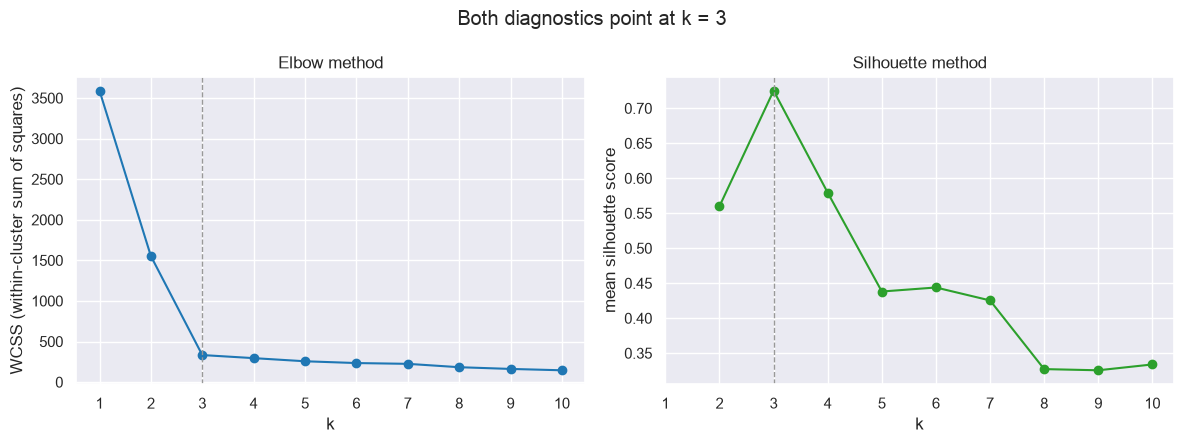

In [5]:
fig, (ax_elbow, ax_sil) = plt.subplots(1, 2, figsize=(12, 4.5))

ks = list(k_values)

ax_elbow.plot(ks, wcss, marker="o", color="tab:blue")
ax_elbow.axvline(3, color="0.6", ls="--", lw=1)
ax_elbow.set_title("Elbow method")
ax_elbow.set_xlabel("k")
ax_elbow.set_ylabel("WCSS (within-cluster sum of squares)")
ax_elbow.set_xticks(ks)

# silhouette is nan at k=1; plot from k=2 so the line has somewhere to start
ax_sil.plot(ks[1:], silhouette[1:], marker="o", color="tab:green")
ax_sil.axvline(best_k, color="0.6", ls="--", lw=1)
ax_sil.set_title("Silhouette method")
ax_sil.set_xlabel("k")
ax_sil.set_ylabel("mean silhouette score")
ax_sil.set_xticks(ks)

fig.suptitle("Both diagnostics point at k = 3")
fig.tight_layout()
plt.show()

Both diagnostics agree here. The **WCSS** curve drops steeply from `k=1`
to `k=3` — each of those clusters is carving a real blob out of the data —
then flattens: past `k=3` every extra centroid just splits an already-tight
blob, shaving a little off the total without earning its keep. The bend at
`k=3` is the elbow.

The **silhouette** curve makes the same call more directly: it peaks at
`k=3` (points sit deep inside well-separated clusters) and falls off on
either side — too few clusters merge distinct blobs, too many slice one
blob into pieces that are then close to their neighbours. When the two
methods disagree, the elbow tends to favour the coarser grouping and the
silhouette the more separated one; here there's no tension.

## k-means vs k-medians: robustness to outliers

k-means updates each centroid to the **mean** of its points, and the mean
is not robust — a few points far from the pack drag it a long way. k-medians
(`flavor="kmedians"`) swaps two things: points are assigned by **Manhattan**
distance, and each centroid updates to the **coordinate-wise median**, which
barely moves when a handful of points fly off to the edge.

To see the difference we need a dataset where it matters, so the three blobs
below stay put but get **8 extreme outliers** streaming out along the +x axis
from the right-hand blob — far enough to distort a centroid, close enough
that they still get assigned to that cluster rather than forming their own.

In [6]:
rng = np.random.default_rng(3)

blob_centers = np.array([[0.0, 0.0], [10.0, 0.0], [5.0, 9.0]])
n_per_cluster = 80
core = np.vstack(
    [c + rng.normal(0, 0.7, (n_per_cluster, 2)) for c in blob_centers]
)

# 8 outliers streaming out along +x from the right-hand blob at (10, 0).
outliers = np.column_stack([rng.uniform(22, 34, 8), rng.uniform(-3, 4, 8)])

points_out = np.vstack([core, outliers])
df_out = pl.DataFrame({"x1": points_out[:, 0], "x2": points_out[:, 1]})

data_out = DolceSet()
data_out.load_from_polars_dataframe(df_out)

print(f"{len(core)} blob points + {len(outliers)} outliers")

240 blob points + 8 outliers


### Fit both, same data, same init

Both fits use `k=3` and `"kmeans++"` init on the *same* points; the only
difference is `flavor`. We then measure how far each method's right-hand
centroid lands from the true blob centre at `(10, 0)` — the outliers all
belong to that cluster, so that centroid is where the two methods part ways.

In [7]:
fits = {}
for flavor in ("kmeans", "kmedians"):
    np.random.seed(2)  # 'kmeans++' still draws its first centroid from the global RNG
    model = KMeans()
    model.fit(data_out, k=3, init_strategy="kmeans++", flavor=flavor, max_iters=100)
    fits[flavor] = model.centroids

right_true = np.array([10.0, 0.0])
for flavor, cents in fits.items():
    right = cents[np.argmin(np.linalg.norm(cents - right_true, axis=1))]
    drift = np.linalg.norm(right - right_true)
    print(f"{flavor:9s} right-blob centroid = {np.round(right, 2)}   drift from (10, 0) = {drift:.2f}")

kmeans    right-blob centroid = [11.69  0.07]   drift from (10, 0) = 1.69
kmedians  right-blob centroid = [10.05  0.06]   drift from (10, 0) = 0.08


### Side by side

Same points on both panels. Blue crosses are the true blob centres; the
diamonds are the fitted centroids. The left blob and the top blob land in
the same place either way — but the right-hand k-means centroid is visibly
tugged toward the outlier stream, while k-medians stays pinned on the blob.

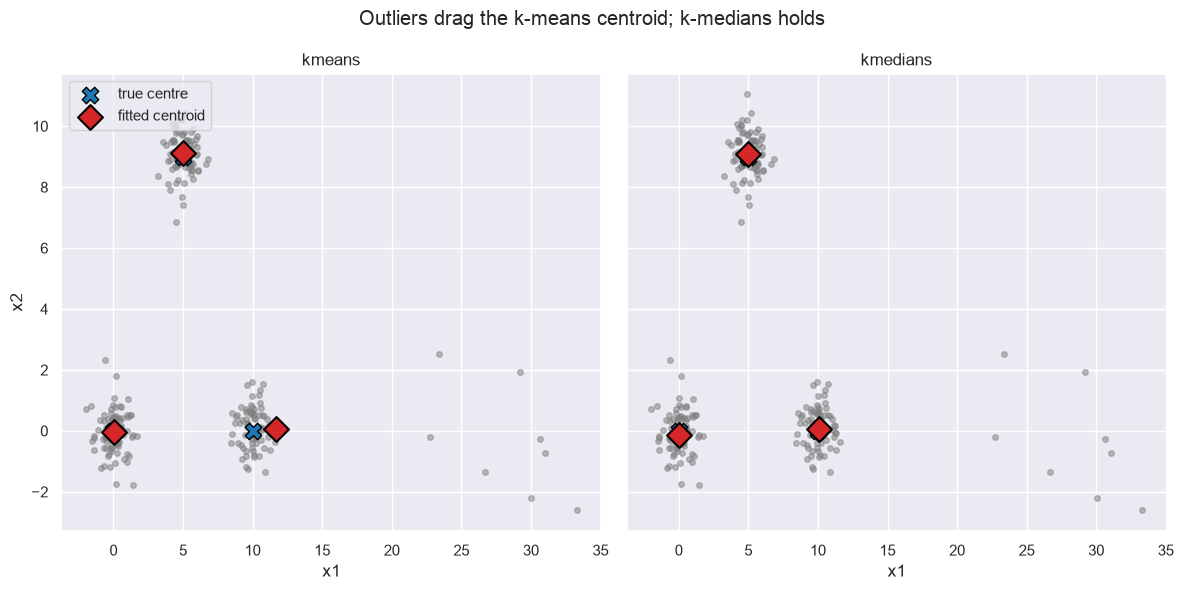

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

for ax, flavor in zip(axes, ("kmeans", "kmedians")):
    ax.scatter(points_out[:, 0], points_out[:, 1], s=16, alpha=0.5, color="0.5")
    ax.scatter(
        blob_centers[:, 0], blob_centers[:, 1],
        marker="X", s=140, color="tab:blue", edgecolors="black", linewidths=1,
        zorder=3, label="true centre",
    )
    ax.scatter(
        fits[flavor][:, 0], fits[flavor][:, 1],
        marker="D", s=160, color="tab:red", edgecolors="black", linewidths=1.5,
        zorder=4, label="fitted centroid",
    )
    ax.set_title(flavor)
    ax.set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].legend(loc="upper left")
fig.suptitle("Outliers drag the k-means centroid; k-medians holds")
fig.tight_layout()
plt.show()

## Hierarchical clustering

k-means and k-medians both need `k` fixed in advance and both describe a
cluster by a single point (a mean or a median), which makes every cluster
boundary an intersection of circles (Euclidean) or diamonds (Manhattan) —
fine for blobs, but blind to clusters with any other shape.

**Agglomerative hierarchical clustering** takes a different approach: start
with every observation in its own cluster, then repeatedly merge the two
*closest* clusters until only one remains. No `k` is chosen up front — the
whole merge sequence is recorded as a **dendrogram**, a tree whose leaves are
the individual points and whose internal nodes are merges, each drawn at the
height (distance) at which it happened. A flat clustering falls out by
cutting the dendrogram at any height or number of clusters, after the fact.

`HierarchicalClustering.fit` needs one more ingredient than k-means: once two
clusters merge, what is the distance from the *merged* cluster to every other
one? That choice is the **linkage**, and it's what this section is about:

- **single** — distance to the *closest* pair of points, one from each
  cluster. Clusters merge as soon as their nearest edges touch, so a chain of
  close points can link two otherwise distant regions together (chaining).
- **complete** — distance to the *farthest* pair of points. The opposite
  bias: it refuses to merge until every point in one cluster is close to
  every point in the other, which favours compact, similarly-sized clusters.
- **average** — the mean distance over *all* cross-cluster pairs. A
  compromise between single and complete.
- **ward** — the merge that increases within-cluster variance the least
  (the same quantity k-means minimises). Tends to produce k-means-like,
  roughly spherical clusters.

All four are computed via the **Lance-Williams recurrence**
(`apply_lance_williams_formula`), which updates the distance from a merged
cluster to every other cluster directly from the distances that were already
known, without revisiting the original points.

### Same blobs, four linkages

We reuse the three-blob dataset from the very first section — the one
k-means solved cleanly with `k=3` — and fit `HierarchicalClustering` on it
once per linkage. `fit` returns nothing; the dendrogram nodes are stored on
`self.clusters` (leaves first, root last) and drawn with `plot_dendrogram`.

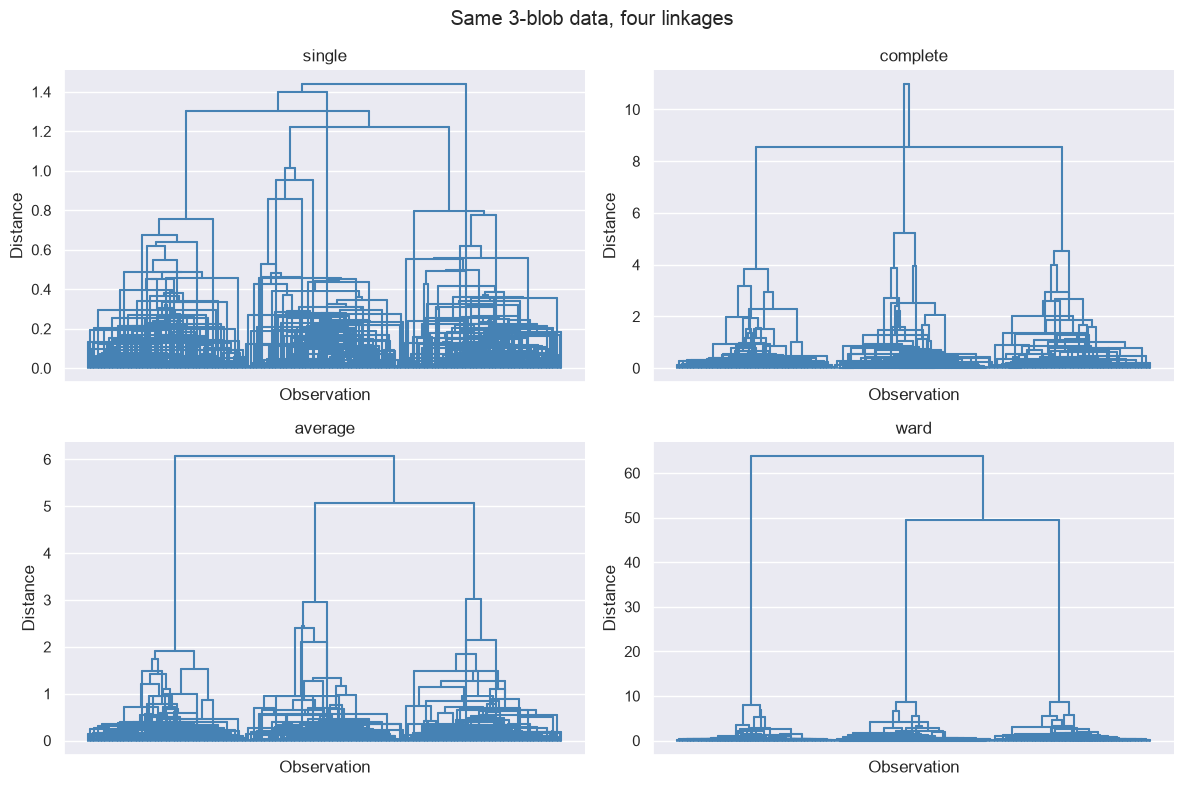

In [9]:
from dolcestat.clustering import HierarchicalClustering

linkages = ["single", "complete", "average", "ward"]
hc_fits = {}
for linkage in linkages:
    model = HierarchicalClustering()
    model.fit(data, linkage=linkage)
    hc_fits[linkage] = model

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, linkage in zip(axes.ravel(), linkages):
    hc_fits[linkage].plot_dendrogram(ax=ax)
    ax.set_title(linkage)
    ax.set_xticks([])  # 300 leaves -- labels would overlap
fig.suptitle("Same 3-blob data, four linkages")
fig.tight_layout()
plt.show()

On well-separated blobs, the linkage choice mostly shows up in the
dendrogram's *shape*, not its final clusters. **Complete**, **average** and
**ward** all show three clean, roughly balanced towers that merge late and
high — three real groups, cleanly separated. **Single** looks different: it
still finds three groups at the bottom, but tends to grow one by attaching
points one at a time (a staircase pattern) rather than merging whole
sub-clusters symmetrically — the chaining effect mentioned above, visible
even when it doesn't change the final clusters.

To get an actual partition out of a dendrogram it has to be **cut**: pick a
number of clusters `k`, then undo merges from the top until exactly `k`
remain (equivalently, cut the tree at the height of the `k`-th-from-last
merge). The library doesn't ship a cutting function — dendrograms are the
deliverable — so here's a short one, built directly from `self.clusters`:
merges are stored in the order they happened, so keeping only the first
`n - k` of them and propagating membership through the rest recovers the
`k`-cluster labels.

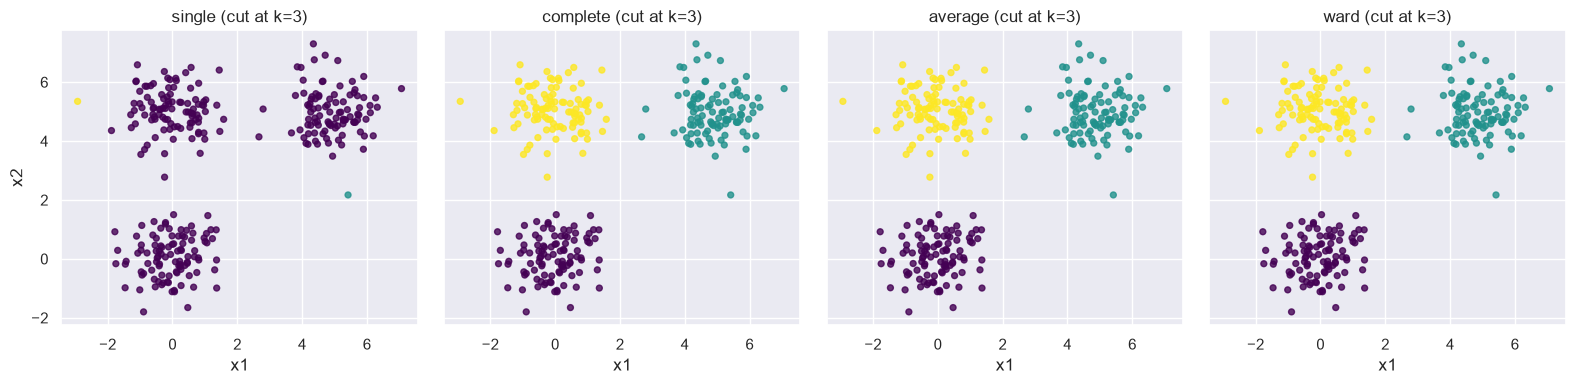

In [10]:
def cut_tree(clusters, n_points, k):
    """Flat cluster labels obtained by cutting a fitted dendrogram at `k` clusters.

    `clusters` is `HierarchicalClustering.clusters`: the leaves (one per
    point) followed by every merge in the order it happened, ending with the
    root. Replaying only the first `n_points - k` merges leaves exactly `k`
    groups; each later merge is skipped, so its two children stay separate.
    """
    n_merges_to_keep = n_points - k
    labels = np.arange(n_points)
    for merge in clusters[n_points : n_points + n_merges_to_keep]:
        target = labels[merge.members_ids[0]]
        for member_id in merge.members_ids:
            labels[member_id] = target
    _, labels = np.unique(labels, return_inverse=True)  # relabel to 0..k-1
    return labels


fig, axes = plt.subplots(1, len(linkages), figsize=(4 * len(linkages), 4), sharex=True, sharey=True)
for ax, linkage in zip(axes, linkages):
    hc_labels = cut_tree(hc_fits[linkage].clusters, X.shape[0], k=3)
    ax.scatter(X[:, 0], X[:, 1], c=hc_labels, cmap="viridis", s=18, alpha=0.8)
    ax.set_title(f"{linkage} (cut at k=3)")
    ax.set_xlabel("x1")
axes[0].set_ylabel("x2")
fig.tight_layout()
plt.show()

## Non-convex clusters: where k-means breaks

All four linkages basically agree on the blobs, and so does k-means — because
every cluster there really is a round, convex blob, which is the one shape
k-means is built to find (it assigns each point to its *nearest centroid*,
so every cluster boundary is a chunk of a Voronoi diagram: an intersection of
half-planes, never a shape that curves around another cluster).

To see that limitation, we need data where the clusters aren't blobs: two
concentric rings, one inside the other. There is no `k=2` set of centroids
whose nearest-centroid regions trace out a ring — one centroid roughly at
the shared centre pulls in points from *both* rings, so k-means has to fail.
Single linkage, by contrast, builds clusters by chaining nearby points
together rather than gathering them around a centre, so it doesn't care
whether that chain curves.

### Data: two concentric rings

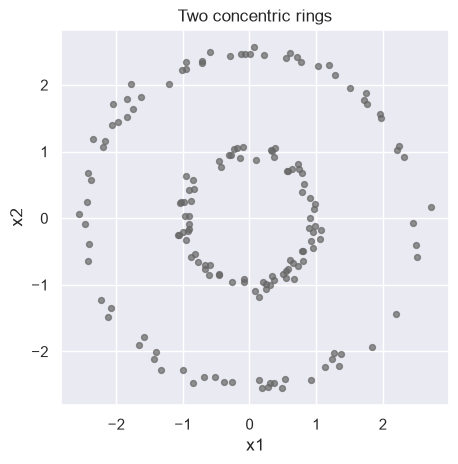

In [11]:
rng = np.random.default_rng(1)
n_per_ring = 80
inner_radius, outer_radius = 1.0, 2.5
noise = 0.08

angles_inner = rng.uniform(0, 2 * np.pi, n_per_ring)
angles_outer = rng.uniform(0, 2 * np.pi, n_per_ring)
inner = inner_radius * np.column_stack([np.cos(angles_inner), np.sin(angles_inner)])
outer = outer_radius * np.column_stack([np.cos(angles_outer), np.sin(angles_outer)])

X_rings = np.vstack([outer, inner]) + rng.normal(0, noise, (2 * n_per_ring, 2))
true_ring = np.array([0] * n_per_ring + [1] * n_per_ring)  # ground truth, for scoring only

df_rings = pl.DataFrame({"x1": X_rings[:, 0], "x2": X_rings[:, 1]})
data_rings = DolceSet()
data_rings.load_from_polars_dataframe(df_rings)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X_rings[:, 0], X_rings[:, 1], s=18, alpha=0.7, color="0.4")
ax.set_title("Two concentric rings")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_aspect("equal")
plt.show()

### Fit k-means and every linkage, k = 2

Same data, same target of 2 clusters, one fit per method. To check each
result against the true inner/outer split we need a label-agreement score:
cluster labels are arbitrary (hierarchical's "0" has no reason to line up
with k-means' "0"), so we score both ways the two labels could be paired up
and keep the better one.

In [12]:
def label_agreement(true_labels, pred_labels):
    """Fraction of points on which two 2-way labelings agree, best of the 2 pairings."""
    return max(
        np.mean(true_labels == pred_labels),
        np.mean(true_labels == 1 - pred_labels),
    )


np.random.seed(0)  # 'kmeans++' draws its first centroid from the global RNG
kmeans_rings = KMeans()
kmeans_rings.fit(data_rings, k=2, init_strategy="kmeans++")

ring_labels = {"kmeans": kmeans_rings.labels}
hc_rings_fits = {}
for linkage in linkages:
    model = HierarchicalClustering()
    model.fit(data_rings, linkage=linkage)
    hc_rings_fits[linkage] = model
    ring_labels[linkage] = cut_tree(model.clusters, X_rings.shape[0], k=2)

print(f"{'method':>10}  {'agreement':>10}")
for method, labels in ring_labels.items():
    print(f"{method:>10}  {label_agreement(true_ring, labels):>10.2%}")

    method   agreement
    kmeans      58.13%
    single     100.00%
  complete      59.38%
   average      68.12%
      ward      56.25%


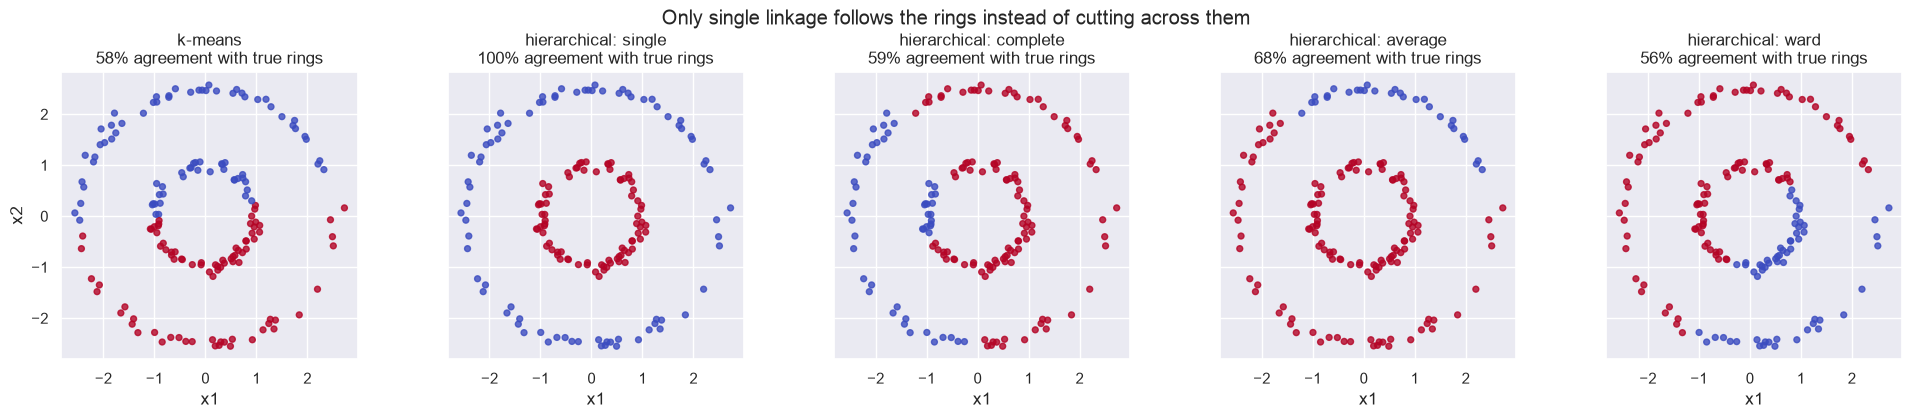

In [13]:
methods = ["kmeans", *linkages]

fig, axes = plt.subplots(1, len(methods), figsize=(4 * len(methods), 4), sharex=True, sharey=True)
for ax, method in zip(axes, methods):
    labels = ring_labels[method]
    ax.scatter(X_rings[:, 0], X_rings[:, 1], c=labels, cmap="coolwarm", s=18, alpha=0.8)
    agreement = label_agreement(true_ring, labels)
    title = "k-means" if method == "kmeans" else f"hierarchical: {method}"
    ax.set_title(f"{title}\n{agreement:.0%} agreement with true rings")
    ax.set_xlabel("x1")
    ax.set_aspect("equal")
axes[0].set_ylabel("x2")
fig.suptitle("Only single linkage follows the rings instead of cutting across them")
fig.tight_layout()
plt.show()

**k-means, complete, average and ward all fail the same way**, and for the
same underlying reason: every one of them summarises a cluster by an
average behaviour over its members (a centroid, or a farthest/mean pairwise
distance that rewards compactness), so each is implicitly hunting for round,
similarly-sized groups. Since half of *each* ring sits right next to half of
the *other* ring, the two "clusters" that best minimise a centroid-style
objective are the left half and the right half of the whole figure — cutting
straight across both rings — which is exactly the near-50% agreement they
land on.

**Single linkage gets it exactly right.** It never asks "are these two
groups close *on average*?" — only "is there some point in the other group
close to *some* point in this one?" Walking around a ring, every point has a
close neighbour a short arc away, so the whole ring chains together into one
cluster long before either ring gets close enough to the other to merge with
it. The same chaining effect that looked like a quirk in the dendrogram
shape on the blobs (the staircase pattern) is precisely the mechanism that
lets it trace a curve k-means structurally cannot represent.

This is also single linkage's weak point in general: chaining means it can
be fooled by a thin bridge of noise between two otherwise-distinct clusters,
merging them early. There's no universally "best" linkage — complete,
average and ward suit compact, blob-like clusters (and are less sensitive to
noisy outlier points along the way), while single linkage is the one to
reach for when the clusters are expected to have irregular or elongated
shapes.